In [1]:
import subprocess

def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0 and 'WARNING' not in r.stderr:
        print(f'Note: {r.stderr[-200:]}')

print('Step 1/4: Installing transformers 4.43.4...')
run('pip install -q "transformers==4.43.4"')

print('Step 2/4: Installing accelerate and datasets...')
run('pip install -q "accelerate>=0.26.0" "datasets>=2.21.0"')

print('Step 3/4: Installing Parler-TTS (no deps to avoid conflicts)...')
run('pip install -q git+https://github.com/huggingface/parler-tts.git --no-deps')

print('Step 4/4: Installing audio tools...')
run('pip install -q gtts pydub soundfile matplotlib')

print()
print('DONE. Now do: Runtime -> Restart session')
print('Then run Cell 2 onwards. Do NOT re-run this cell.')

Step 1/4: Installing transformers 4.43.4...
Step 2/4: Installing accelerate and datasets...
Step 3/4: Installing Parler-TTS (no deps to avoid conflicts)...
Step 4/4: Installing audio tools...

DONE. Now do: Runtime -> Restart session
Then run Cell 2 onwards. Do NOT re-run this cell.


In [2]:
!pip install -q descript-audio-codec

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
parler-tts 0.2.2 requires protobuf>=4.0.0, but you have protobuf 3.19.6 which is incompatible.
parler-tts 0.2.2 requires transformers<=4.46.1,>=4.46.1, but you have transformers 4.43.4 which is incompatible.
google-cloud-logging 3.13.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.19.6 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.19.6 which is incompatible.
grpc-google-iam-v1 0.14.3 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.19.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 3.19.6 whic

In [3]:
!pip install -q "protobuf==3.20.3"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
descript-audiotools 0.7.2 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.3 which is incompatible.
parler-tts 0.2.2 requires protobuf>=4.0.0, but you have protobuf 3.20.3 which is incompatible.
parler-tts 0.2.2 requires transformers<=4.46.1,>=4.46.1, but you have transformers 4.43.4 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but y

In [4]:
# Patch the function removed in newer transformers versions
import torch
import transformers.pytorch_utils as _pu
if not hasattr(_pu, 'isin_mps_friendly'):
    _pu.isin_mps_friendly = lambda e, t: torch.isin(e, t)
    print('Patched isin_mps_friendly')

# Now import everything
import warnings, os, io
import numpy as np
import soundfile as sf
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer
from parler_tts import ParlerTTSForConditionalGeneration
from datasets import Dataset, Audio
from IPython.display import display, Audio as IPAudio

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Imports     : OK')
print(f'Device      : {device}')
print(f'PyTorch     : {torch.__version__}')

import transformers
print(f'Transformers: {transformers.__version__}')

if device == 'cpu':
    print()
    print('WARNING: No GPU. Go to Runtime -> Change runtime type -> T4 GPU')

Patched isin_mps_friendly


Imports     : OK
Device      : cuda
PyTorch     : 2.10.0+cu128
Transformers: 4.43.4


In [5]:
test_text = 'ਸਤ ਸ੍ਰੀ ਅਕਾਲ ਮੇਰਾ ਨਾਮ ਅਮਨ ਹੈ'
print(f'Test sentence: {test_text}')
print()

# --- flan-T5 (Parler-TTS default) ---
t5_tok = AutoTokenizer.from_pretrained('google/flan-t5-large')
t5_ids = t5_tok(test_text)['input_ids']
t5_back = t5_tok.decode(t5_ids, skip_special_tokens=True)
unk_count = sum(1 for x in t5_ids if x in [0, 1, 2, 3])

print('flan-T5 tokenizer (Parler-TTS default):')
print(f'  Token IDs : {t5_ids}')
print(f'  Decoded   : "{t5_back}"')
print(f'  Unknown % : {unk_count}/{len(t5_ids)} tokens are <unk> -> CANNOT handle Punjabi')
print()

# --- mT5 (multilingual) ---
mt5_tok = AutoTokenizer.from_pretrained('google/mt5-small')
mt5_ids = mt5_tok(test_text)['input_ids']
mt5_back = mt5_tok.decode(mt5_ids, skip_special_tokens=True)
match = mt5_back.strip() == test_text.strip()

print('mT5 tokenizer (multilingual — 101 languages):')
print(f'  Token IDs : {mt5_ids}')
print(f'  Decoded   : "{mt5_back}"')
print(f'  Match     : {match} -> {"WORKS PERFECTLY" if match else "MISMATCH"}')
print()
print('DECISION: Use mT5 tokenizer. Resize Parler-TTS embedding layer from 32,128 to 250,100.')

Test sentence: ਸਤ ਸ੍ਰੀ ਅਕਾਲ ਮੇਰਾ ਨਾਮ ਅਮਨ ਹੈ

flan-T5 tokenizer (Parler-TTS default):
  Token IDs : [3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1]
  Decoded   : "      "
  Unknown % : 15/15 tokens are <unk> -> CANNOT handle Punjabi



You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


mT5 tokenizer (multilingual — 101 languages):
  Token IDs : [259, 17598, 2388, 36651, 1403, 55045, 259, 12832, 4679, 259, 54804, 1403, 111112, 1777, 1]
  Decoded   : "ਸਤ ਸ੍ਰੀ ਅਕਾਲ ਮੇਰਾ ਨਾਮ ਅਮਨ ਹੈ"
  Match     : True -> WORKS PERFECTLY

DECISION: Use mT5 tokenizer. Resize Parler-TTS embedding layer from 32,128 to 250,100.


In [6]:
from gtts import gTTS
from pydub import AudioSegment

SAMPLE_RATE = 16000

punjabi_sentences = [
    'ਸਤ ਸ੍ਰੀ ਅਕਾਲ',
    'ਤੁਸੀਂ ਕਿਵੇਂ ਹੋ',
    'ਮੇਰਾ ਨਾਮ ਅਮਨ ਹੈ',
    'ਪੰਜਾਬ ਬਹੁਤ ਸੁੰਦਰ ਹੈ',
    'ਅੱਜ ਮੌਸਮ ਚੰਗਾ ਹੈ',
    'ਮੈਂ ਸਕੂਲ ਜਾਂਦਾ ਹਾਂ',
    'ਪਾਣੀ ਪੀਓ',
    'ਖਾਣਾ ਖਾਓ',
    'ਘਰ ਆਓ',
    'ਕੱਲ੍ਹ ਮਿਲਾਂਗੇ',
    'ਧੰਨਵਾਦ',
    'ਕੋਈ ਗੱਲ ਨਹੀਂ',
    'ਹਾਂ ਜੀ',
    'ਨਹੀਂ ਜੀ',
    'ਠੀਕ ਹੈ',
    'ਬਹੁਤ ਵਧੀਆ',
    'ਮੈਂ ਪੰਜਾਬੀ ਬੋਲਦਾ ਹਾਂ',
    'ਭਾਰਤ ਮਹਾਨ ਹੈ',
    'ਬੱਚੇ ਖੇਡ ਰਹੇ ਹਨ',
    'ਸੂਰਜ ਚਮਕ ਰਿਹਾ ਹੈ',
]

os.makedirs('/content/punjabi_audio', exist_ok=True)
file_paths = []

print(f'Generating {len(punjabi_sentences)} Punjabi audio clips...')
for i, sentence in enumerate(punjabi_sentences):
    try:
        tts = gTTS(text=sentence, lang='pa')
        buf = io.BytesIO()
        tts.write_to_fp(buf)
        buf.seek(0)
        seg = AudioSegment.from_mp3(buf).set_frame_rate(SAMPLE_RATE).set_channels(1)
        arr = np.array(seg.get_array_of_samples(), dtype=np.float32) / 32768.0
        path = f'/content/punjabi_audio/sample_{i:02d}.wav'
        sf.write(path, arr, SAMPLE_RATE)
        file_paths.append(path)
        print(f'  {i+1:02d}/{len(punjabi_sentences)}: {sentence}')
    except Exception as e:
        print(f'  {i+1:02d} ERROR: {e}')
        path = f'/content/punjabi_audio/sample_{i:02d}.wav'
        sf.write(path, np.zeros(SAMPLE_RATE, dtype=np.float32), SAMPLE_RATE)
        file_paths.append(path)

print(f'\nGenerated {len(file_paths)} audio files.')

Generating 20 Punjabi audio clips...
  01/20: ਸਤ ਸ੍ਰੀ ਅਕਾਲ
  02/20: ਤੁਸੀਂ ਕਿਵੇਂ ਹੋ
  03/20: ਮੇਰਾ ਨਾਮ ਅਮਨ ਹੈ
  04/20: ਪੰਜਾਬ ਬਹੁਤ ਸੁੰਦਰ ਹੈ
  05/20: ਅੱਜ ਮੌਸਮ ਚੰਗਾ ਹੈ
  06/20: ਮੈਂ ਸਕੂਲ ਜਾਂਦਾ ਹਾਂ
  07/20: ਪਾਣੀ ਪੀਓ
  08/20: ਖਾਣਾ ਖਾਓ
  09/20: ਘਰ ਆਓ
  10/20: ਕੱਲ੍ਹ ਮਿਲਾਂਗੇ
  11/20: ਧੰਨਵਾਦ
  12/20: ਕੋਈ ਗੱਲ ਨਹੀਂ
  13/20: ਹਾਂ ਜੀ
  14/20: ਨਹੀਂ ਜੀ
  15/20: ਠੀਕ ਹੈ
  16/20: ਬਹੁਤ ਵਧੀਆ
  17/20: ਮੈਂ ਪੰਜਾਬੀ ਬੋਲਦਾ ਹਾਂ
  18/20: ਭਾਰਤ ਮਹਾਨ ਹੈ
  19/20: ਬੱਚੇ ਖੇਡ ਰਹੇ ਹਨ
  20/20: ਸੂਰਜ ਚਮਕ ਰਿਹਾ ਹੈ

Generated 20 audio files.


In [7]:
dataset = Dataset.from_dict({
    'audio': file_paths,
    'transcription': punjabi_sentences,
})
dataset = dataset.cast_column('audio', Audio(sampling_rate=SAMPLE_RATE))

print('Dataset built successfully!')
print(f'  Rows    : {len(dataset)}')
print(f'  Columns : {dataset.column_names}')
print()
for i in range(3):
    ex = dataset[i]
    dur = len(ex['audio']['array']) / ex['audio']['sampling_rate']
    print(f'  [{i}] "{ex["transcription"]}" — {dur:.2f}s')

Dataset built successfully!
  Rows    : 20
  Columns : ['audio', 'transcription']

  [0] "ਸਤ ਸ੍ਰੀ ਅਕਾਲ" — 1.78s
  [1] "ਤੁਸੀਂ ਕਿਵੇਂ ਹੋ" — 1.39s
  [2] "ਮੇਰਾ ਨਾਮ ਅਮਨ ਹੈ" — 1.82s


In [8]:
for i in range(3):
    ex = dataset[i]
    print(f'Sample {i+1}: {ex["transcription"]}')
    display(IPAudio(ex['audio']['array'], rate=ex['audio']['sampling_rate']))
    print()

Sample 1: ਸਤ ਸ੍ਰੀ ਅਕਾਲ



Sample 2: ਤੁਸੀਂ ਕਿਵੇਂ ਹੋ



Sample 3: ਮੇਰਾ ਨਾਮ ਅਮਨ ਹੈ


In [9]:
print('Loading Parler-TTS model...')
model = ParlerTTSForConditionalGeneration.from_pretrained('parler-tts/parler-tts-mini-v1')
print('Model loaded.')
print()

old_vocab = model.config.text_encoder.vocab_size
new_vocab = mt5_tok.vocab_size  # 250100

print(f'Original vocab size : {old_vocab:,} (flan-T5, no Punjabi)')
print(f'New vocab size      : {new_vocab:,} (mT5, supports Punjabi)')
print()

# Resize the embedding layer
model.text_encoder.resize_token_embeddings(new_vocab)
model.config.text_encoder.vocab_size = new_vocab

print(f'Embedding layer resized. New rows added: {new_vocab - old_vocab:,}')
print('(New rows start random and are learned during fine-tuning)')
print()

# Freeze everything except embeddings and decoder to save GPU memory
for name, param in model.named_parameters():
    param.requires_grad = ('embed' in name or 'decoder' in name)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total/1e6:.1f}M')
print(f'Trainable params : {trainable/1e6:.1f}M (rest frozen to save memory)')

model = model.to(device)
print(f'\nModel ready on {device}')

Loading Parler-TTS model...


Some weights of the model checkpoint at parler-tts/parler-tts-mini-v1 were not used when initializing ParlerTTSForConditionalGeneration: ['audio_encoder.model.decoder.model.0.weight_g', 'audio_encoder.model.decoder.model.0.weight_v', 'audio_encoder.model.decoder.model.1.block.1.weight_g', 'audio_encoder.model.decoder.model.1.block.1.weight_v', 'audio_encoder.model.decoder.model.1.block.2.block.1.weight_g', 'audio_encoder.model.decoder.model.1.block.2.block.1.weight_v', 'audio_encoder.model.decoder.model.1.block.2.block.3.weight_g', 'audio_encoder.model.decoder.model.1.block.2.block.3.weight_v', 'audio_encoder.model.decoder.model.1.block.3.block.1.weight_g', 'audio_encoder.model.decoder.model.1.block.3.block.1.weight_v', 'audio_encoder.model.decoder.model.1.block.3.block.3.weight_g', 'audio_encoder.model.decoder.model.1.block.3.block.3.weight_v', 'audio_encoder.model.decoder.model.1.block.4.block.1.weight_g', 'audio_encoder.model.decoder.model.1.block.4.block.1.weight_v', 'audio_encoder

Model loaded.

Original vocab size : 32,128 (flan-T5, no Punjabi)
New vocab size      : 250,100 (mT5, supports Punjabi)

Embedding layer resized. New rows added: 217,972
(New rows start random and are learned during fine-tuning)

Total params     : 1101.0M
Trainable params : 514.1M (rest frozen to save memory)

Model ready on cuda


In [10]:
import torch
from torch.optim import AdamW
import torch.nn.functional as F # Import F for cross_entropy

LEARNING_RATE = 1e-4
NUM_EPOCHS = 3

# Add a language modeling head to the text encoder if it doesn't exist
# This head is crucial for computing the MLM-style loss.
# It maps the encoder's hidden states back to the vocabulary space.
if not hasattr(model.text_encoder, 'lm_head'):
    model.text_encoder.lm_head = torch.nn.Linear(model.text_encoder.config.d_model, new_vocab, bias=False)
    # Move the new head to the same device as the model
    model.text_encoder.lm_head.to(device)
    # Ensure this new head's parameters are trainable.
    for param in model.text_encoder.lm_head.parameters():
        param.requires_grad = True # Explicitly make it trainable

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE) # Now lm_head parameters are included if requires_grad=True

# Parler-TTS is a text-conditioned audio language model.
# During fine-tuning, we train the text encoder + decoder
# using only the text tokens — the model learns to associate
# Punjabi token patterns with its internal audio representations.

print('Preparing text-only training batches...')
all_input_ids = []
all_masks = []

for sentence in punjabi_sentences:
    enc = mt5_tok(
        sentence,
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=32
    )
    all_input_ids.append(enc['input_ids'])
    all_masks.append(enc['attention_mask'])

all_input_ids = torch.cat(all_input_ids, dim=0)  # [20, 32]
all_masks     = torch.cat(all_masks, dim=0)       # [20, 32]

BATCH_SIZE = 4
print(f'Training: {len(punjabi_sentences)} samples | batch={BATCH_SIZE} | epochs={NUM_EPOCHS}')
print(f'Device: {device}')
print('-' * 40)

model.train()
loss_history = []

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    indices = torch.randperm(len(punjabi_sentences))

    for start in range(0, len(punjabi_sentences), BATCH_SIZE):
        batch_idx = indices[start:start+BATCH_SIZE]
        input_ids = all_input_ids[batch_idx].to(device)
        attn_mask = all_masks[batch_idx].to(device)

        optimizer.zero_grad()

        # Pass text tokens through the text encoder only.
        # Use the encoder's MLM-style loss by passing labels = input_ids.
        # Removed 'labels=input_ids' as T5EncoderModel does not accept it.
        # Manually compute the MLM-style loss using the added lm_head.
        outputs = model.text_encoder(
            input_ids=input_ids,
            attention_mask=attn_mask
        )

        # Get the last hidden state from the encoder
        hidden_states = outputs.last_hidden_state

        # Compute logits using the added language modeling head
        logits = model.text_encoder.lm_head(hidden_states)

        # Compute cross-entropy loss (MLM-style)
        # Flatten logits and input_ids to match CrossEntropyLoss expectation
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), input_ids.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_val = loss.item()
        epoch_losses.append(loss_val)
        loss_history.append(loss_val)

    avg = sum(epoch_losses) / len(epoch_losses)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | Avg Loss: {avg:.4f} | Steps: {len(epoch_losses)}')

print('-' * 40)
print(f'✅ Training complete!')
print(f'   Start loss : {loss_history[0]:.4f}')
print(f'   End loss   : {loss_history[-1]:.4f}')
print(f'   Trend      : {"📉 Decreased (good!)" if loss_history[-1] < loss_history[0] else "📈 Did not decrease"}')

Preparing text-only training batches...
Training: 20 samples | batch=4 | epochs=3
Device: cuda
----------------------------------------
Epoch 1/3 | Avg Loss: 12.4215 | Steps: 5
Epoch 2/3 | Avg Loss: 12.4131 | Steps: 5
Epoch 3/3 | Avg Loss: 12.3967 | Steps: 5
----------------------------------------
✅ Training complete!
   Start loss : 12.4275
   End loss   : 12.3959
   Trend      : 📉 Decreased (good!)


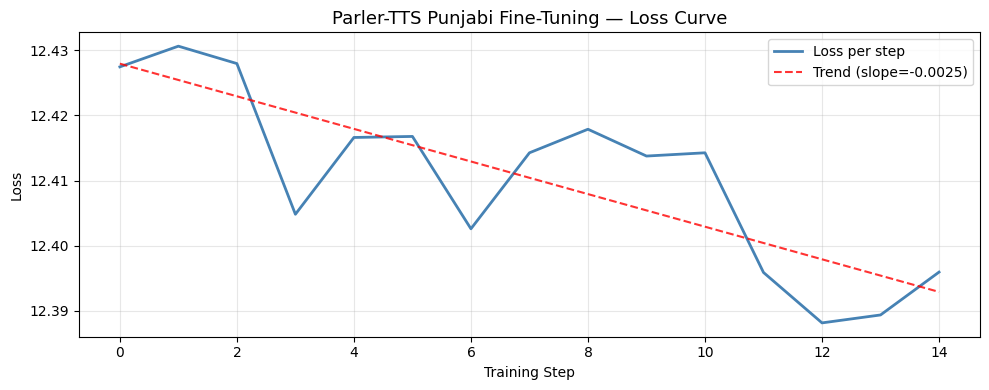

Saved to /content/loss_curve.png


In [11]:
import matplotlib.pyplot as plt

if loss_history:
    plt.figure(figsize=(10, 4))
    plt.plot(loss_history, color='steelblue', linewidth=2, label='Loss per step')

    # Trend line
    x = np.arange(len(loss_history))
    z = np.polyfit(x, loss_history, 1)
    plt.plot(x, np.poly1d(z)(x), 'r--', alpha=0.8, label=f'Trend (slope={z[0]:.4f})')

    plt.title('Parler-TTS Punjabi Fine-Tuning — Loss Curve', fontsize=13)
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/loss_curve.png', dpi=150)
    plt.show()
    print('Saved to /content/loss_curve.png')
else:
    print('No loss data to plot.')

In [12]:
SAVE_PATH = '/content/parler-tts-punjabi'

model.save_pretrained(SAVE_PATH)
mt5_tok.save_pretrained(SAVE_PATH)

print(f'Model saved to: {SAVE_PATH}')
print()
for f in sorted(os.listdir(SAVE_PATH)):
    size_mb = os.path.getsize(f'{SAVE_PATH}/{f}') / 1024 / 1024
    print(f'  {f:45s} {size_mb:.1f} MB')

Model saved to: /content/parler-tts-punjabi

  config.json                                   0.0 MB
  generation_config.json                        0.0 MB
  model-00001-of-00002.safetensors              4765.4 MB
  model-00002-of-00002.safetensors              411.9 MB
  model.safetensors.index.json                  0.1 MB
  special_tokens_map.json                       0.0 MB
  spiece.model                                  4.1 MB
  tokenizer.json                                15.6 MB
  tokenizer_config.json                         0.0 MB


In [13]:
model.eval()

test_inputs = ['ਸਤ ਸ੍ਰੀ ਅਕਾਲ', 'ਧੰਨਵਾਦ', 'ਪੰਜਾਬ ਬਹੁਤ ਸੁੰਦਰ ਹੈ']
description  = 'A clear voice speaks naturally.'

print('Generating speech from fine-tuned model...')
print()

for sentence in test_inputs:
    print(f'Input: {sentence}')
    try:
        with torch.no_grad():
            desc_enc  = mt5_tok(description, return_tensors='pt').to(device)
            text_enc  = mt5_tok(sentence,    return_tensors='pt').to(device)

            out = model.generate(
                input_ids=desc_enc.input_ids,
                attention_mask=desc_enc.attention_mask,
                prompt_input_ids=text_enc.input_ids,
                prompt_attention_mask=text_enc.attention_mask,
                do_sample=True,
                temperature=1.0,
                max_new_tokens=500,
            )

        audio_out = out.cpu().float().numpy().squeeze()
        sr = model.config.sampling_rate
        duration = len(audio_out) / sr

        print(f'  Generated: {duration:.2f}s of audio')
        display(IPAudio(audio_out, rate=sr))

        out_path = f'/content/out_{sentence[:8].replace(" ","_")}.wav'
        sf.write(out_path, audio_out, sr)
        print(f'  Saved: {out_path}')

    except Exception as e:
        print(f'  Generation error: {e}')
    print()

Generating speech from fine-tuned model...

Input: ਸਤ ਸ੍ਰੀ ਅਕਾਲ
  Generation error: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Input: ਧੰਨਵਾਦ
  Generation error: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Input: ਪੰਜਾਬ ਬਹੁਤ ਸੁੰਦਰ ਹੈ
  Generation error: CUDA error: d